In [33]:
#LIBRARIES
import os
import glob
import numpy as np

import matplotlib.pyplot as plt

In [75]:
#GETTING XARRAY
import uxarray as ux
import cartopy.crs as ccrs
import geoviews.feature as gf
import holoviews as hv

In [3]:
# Directory path
model_directory = "/glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.1/MPAS-Model_Global"
static_directory = os.path.join(model_directory,"x1.10242.static.nc")

In [4]:
#GETTING FILE LIST



directory=model_directory
FileList = np.sort([f for f in os.listdir(directory) if f.startswith("history")])
FilePathList = np.sort([
    os.path.join(directory, f) 
    for f in os.listdir(directory) if f.startswith("history")
])
print("Files with prefix 'history':")
for f in FileList:
    print(f)

Files with prefix 'history':
history.2022-06-30_00.00.00.nc
history.2022-06-30_06.00.00.nc
history.2022-06-30_12.00.00.nc
history.2022-06-30_18.00.00.nc
history.2022-07-01_00.00.00.nc
history.2022-07-01_06.00.00.nc
history.2022-07-01_12.00.00.nc
history.2022-07-01_18.00.00.nc
history.2022-07-02_00.00.00.nc
history.2022-07-02_06.00.00.nc
history.2022-07-02_12.00.00.nc
history.2022-07-02_18.00.00.nc
history.2022-07-03_00.00.00.nc


In [5]:
#OPENING UNSTRUCTURED MODEL DATA

In [6]:
#getting grid info
primal_mesh = ux.open_grid(static_directory, use_dual=False)
dual_mesh = ux.open_grid(static_directory, use_dual=True)

In [7]:
# #how to open a single file

# FilePath = FilePathList[7]

# # This will return a uxarray.UxDataset
# ds1 = ux.open_dataset(grid_filename_or_obj=static_directory,
#                      filename_or_obj=FilePath)

In [8]:
#how to open all files
ds1 = ux.open_mfdataset(grid_filename_or_obj=static_directory,
                       paths=FilePathList)

In [9]:
#SELECTING DATA

In [10]:
ds2=ds1.sel(Time="2022-07-01T18:00:00", method="nearest")
ds3=ds2.isel(nVertLevels=0)
variable=ds3['surface_pressure']

In [ ]:
######################################
#SUBSETTING DATA

In [11]:
#SUBSET ALL

In [12]:
variable.plot(cmap='viridis')

:Image   [x,y]   (x_y surface_pressure)

In [13]:
#SUBSET LATLON BOUNDS

In [14]:
# Example: Define a bounding box
lon_bounds = (-150, -50)  # Longitude from -100 to -70
lat_bounds = (0, 90)     # Latitude from 25 to 45

# Subset the UxDataArray
variable_subset = variable.subset.bounding_box(lon_bounds=lon_bounds, lat_bounds=lat_bounds)
variable_subset

<xarray.UxDataArray 'surface_pressure' (n_face: 1327)> Size: 5kB
dask.array<getitem, shape=(1327,), dtype=float32, chunksize=(1327,), chunktype=numpy.ndarray>
Coordinates:
    Time     datetime64[ns] 8B 2022-07-01T18:00:00
Dimensions without coordinates: n_face
Attributes:
    units:      Pa
    long_name:  Diagnosed surface pressure

In [15]:
variable_subset.plot(cmap='viridis')

:Image   [x,y]   (x_y surface_pressure)

In [ ]:
#SUBSET: BOUNDING BOX

In [48]:
#box bounding region

variable_BoundingBox = variable.subset.bounding_box(
    lon_bounds,
    lat_bounds,
)
variable_BoundingBox.plot(cmap='viridis')

:Image   [x,y]   (x_y surface_pressure)

In [60]:
#circular bounding region
center_coord = (40, -105)
r=10 #number of grids

variable_BoundingCircle = variable.subset.bounding_circle(center_coord, r)
variable_BoundingCircle.plot(cmap='viridis')

:Image   [x,y]   (x_y surface_pressure)

In [52]:
#OTHER SUBSETTING OPTIONS
center_coord = (40, -105)
r = 2
variable_subset_ConstLon=variable_subset.subset.constant_longitude(target_lat) #finds all faces that constant latitude line passes through
variable_subset_ConstLon.plot(cmap='viridis')

:Image   [x,y]   (x_y surface_pressure)

In [ ]:
#SUBSET: NEAREST NEIGHBORS

In [45]:
#subset single point

# Define your target point
target_lon, target_lat = -95.0, 30.0
center_coord = (target_lon, target_lat)

# Get nearest face to that point
variable_Point = variable.subset.nearest_neighbor(center_coord, k=1, element='face centers')
# variable_Nearest.plot()
variable_Point.data.compute()


array([100970.43], dtype=float32)

In [83]:
#subset nearest neighbor

# Define your target point
target_lon, target_lat = -95.0, 30.0
center_coord = (target_lon, target_lat)

# Get nearest face to that point
variable_Nearest = variable.subset.nearest_neighbor(center_coord, k=30, element='face centers') #element='nodes'
variable_Nearest.plot()
# variable_Point.data.compute()



:Image   [x,y]   (x_y surface_pressure)

In [ ]:
#SUBSET: CONSTANT LATLON LINES

In [24]:
target_lat = 40.0
variable_subset_ConstLat=variable_subset.subset.constant_latitude(target_lat) #finds all faces that constant latitude line passes through
variable_subset_ConstLat.plot(cmap='viridis')

:Image   [x,y]   (x_y surface_pressure)

In [26]:
target_lat = -105
variable_subset_ConstLon=variable_subset.subset.constant_longitude(target_lat) #finds all faces that constant latitude line passes through
variable_subset_ConstLon.plot(cmap='viridis')

:Image   [x,y]   (x_y surface_pressure)

In [49]:
target_lat = -105
variable_subset_ConstLon=variable_subset.subset.constant_longitude(target_lat) #finds all faces that constant latitude line passes through
variable_subset_ConstLon.plot(cmap='viridis')

:Image   [x,y]   (x_y surface_pressure)

In [ ]:
#SUBSET: CONSTANT LATLON SLICES

In [63]:
#subsetting longitude interval
lons=(-150,-50)
variable_LonInterval=variable_subset.subset.constant_longitude_interval(lons)
variable_LonInterval.plot(cmap='viridis')

:Image   [x,y]   (x_y surface_pressure)

In [67]:
#subsetting latitude interval
lats = (-50, 50)
variable_LatInterval=variable.subset.constant_latitude_interval(lats)
variable_LatInterval.plot(cmap='viridis')

:Image   [x,y]   (x_y surface_pressure)

In [ ]:
#CHECKING IF GRID IS A SUBSET

In [68]:
variable_subset.uxgrid.is_subset

True

In [ ]:
######################################
#PLOTTING

In [72]:
#basic plot
variable.plot(cmap='viridis')

:Image   [x,y]   (x_y surface_pressure)

In [ ]:
#plot with border data

In [82]:
#Plot Settings
plot_opts = {"width": 700, "height": 350}
features = gf.coastline(
    projection=ccrs.PlateCarree(), line_width=1, scale="50m"
) * gf.states(projection=ccrs.PlateCarree(), line_width=1, scale="50m")
clim = (variable.values.min(), variable.values.max())

#Running Plots
variable.plot(
    rasterize=True,
    periodic_elements="exclude",
    clim=clim,
    cmap='viridis',
    title="",
    **plot_opts,
) * features


:Overlay
   .Image.I     :Image   [x,y]   (x_y surface_pressure)
   .Coastline.I :Feature   [Longitude,Latitude]
   .States.I    :Feature   [Longitude,Latitude]

In [ ]:
#COMBINING PLOTS (EXAMPLE)

In [ ]:
# (
#     uxds["psi"].plot(
#         cmap="inferno",
#         periodic_elements="split",
#         height=250,
#         width=500,
#         colorbar=False,
#         ylim=(-90, 90),
#     )
#     + zonal_mean_psi.plot.line(
#         x="psi_zonal_mean",
#         y="latitudes",
#         height=250,
#         width=150,
#         ylabel="",
#         ylim=(-90, 90),
#         xlim=(0.8, 1.2),
#         xticks=[0.8, 0.9, 1.0, 1.1, 1.2],
#         yticks=[-90, -45, 0, 45, 90],
#         grid=True,
#     )
# ).opts(title="Combined Zonal Average & Raster Plot")

In [145]:
######################################
#CROSS SECTIONS
variable2=ds2["qv"]

In [146]:
#Helper Function
def set_lon_lat_xticks(ax, cross_section, n_ticks=6):
    """Utility function to draw stacked lat/lon points along the sampled cross-section"""
    da = cross_section

    N = da.sizes["steps"]
    tick_pos = np.linspace(0, N - 1, n_ticks, dtype=int)
    lons = da["lon"].values[tick_pos]
    lats = da["lat"].values[tick_pos]

    tick_labels = []
    for lon, lat in zip(lons, lats):
        lon_dir = "E" if lon >= 0 else "W"
        lat_dir = "N" if lat >= 0 else "S"
        tick_labels.append(f"{abs(lon):.2f}°{lon_dir}\n{abs(lat):.2f}°{lat_dir}")

    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_labels)

    ax.set_xlabel("Longitude\nLatitude")
    plt.tight_layout()

    return fig, ax

In [147]:
#GREAT CIRCLE CROSS SECTION #*#*

Text(0.5, 1.0, 'Cross Section between (-45, -45) and (45, 45)')

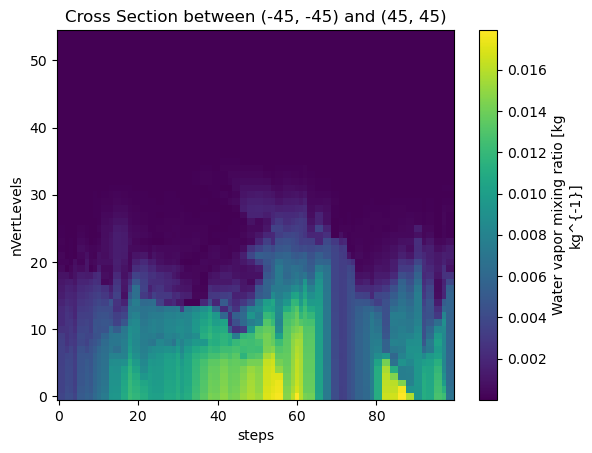

In [158]:

start_point = (-45, -45)
end_point = (45, 45)

cross_section_gca = variable2.cross_section(
    start=start_point, end=end_point, steps=100
)

fig, ax = plt.subplots()
cross_section_gca.T.plot(ax=ax)

# set_lon_lat_xticks(ax, cross_section_gca)
ax.set_title(f"Cross Section between {start_point} and {end_point}")

In [159]:
#CONSTANT LATLON CROSS SECTION #*#*

Text(0.5, 1.0, 'Cross Section at 0° latitude.')

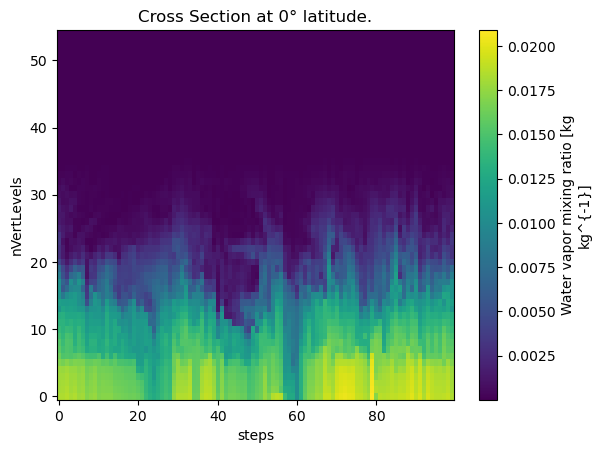

In [161]:
#constant latitude
lat = 0
cross_section_const_lat = variable2.cross_section(lat=lat, steps=100)

fig, ax = plt.subplots()
cross_section_const_lat.T.plot(ax=ax)

# set_lon_lat_xticks(ax, cross_section_const_lat)
ax.set_title(f"Cross Section at {lat}° latitude.")

Text(0.5, 1.0, 'Cross Section at 0° latitude.')

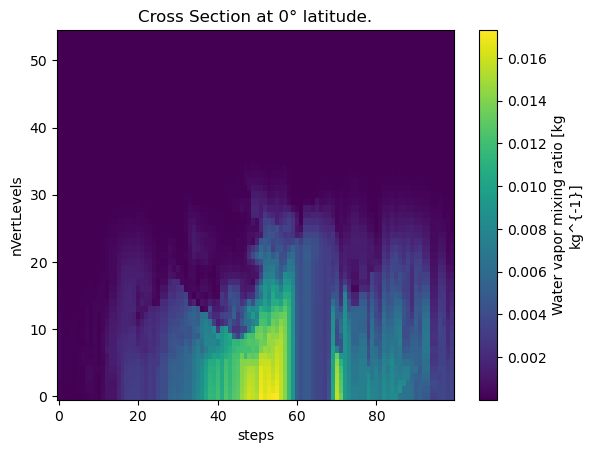

In [162]:
#constant longitude
lon = 0
cross_section_const_lon = variable2.cross_section(lon=lon, steps=100)

fig, ax = plt.subplots()
cross_section_const_lon.T.plot(ax=ax)

# set_lon_lat_xticks(ax, cross_section_const_lon)
ax.set_title(f"Cross Section at {lat}° latitude.")

In [ ]:
######################################
#ZONAL AVERAGING

In [ ]:
# ZONAL MEAN

In [171]:
variable_ZonalMean = variable2.zonal_mean()
variable_ZonalMean.compute()

<xarray.UxDataArray 'qv_zonal_mean' (latitudes: 19, nVertLevels: 55)> Size: 4kB
array([[1.36037306e-05, 1.04091501e-04, 1.19406606e-04, ...,
        3.64093125e-06, 3.52918937e-06, 4.35691572e-06],
       [1.25522944e-04, 1.89860322e-04, 2.43271337e-04, ...,
        3.80051506e-06, 3.98626753e-06, 4.06664276e-06],
       [7.55468907e-04, 7.75656838e-04, 7.88525154e-04, ...,
        3.90844298e-06, 4.15862451e-06, 4.15547947e-06],
       ...,
       [5.34448586e-03, 5.56784822e-03, 5.48073649e-03, ...,
        3.57455133e-06, 4.10468101e-06, 4.52069571e-06],
       [3.60419741e-03, 3.58838099e-03, 3.55874887e-03, ...,
        3.57671115e-06, 4.13713860e-06, 4.58488103e-06],
       [1.15491385e-02, 1.14007350e-02, 1.13260895e-02, ...,
        3.35477262e-06, 3.61776142e-06, 3.75091804e-06]], dtype=float32)
Coordinates:
  * latitudes  (latitudes) int64 152B -90 -80 -70 -60 -50 -40 ... 50 60 70 80 90
Dimensions without coordinates: nVertLevels
Attributes:
    zonal_mean:  True

In [176]:
(variable_ZonalMean.plot.line()).opts(
    title="Zonal Average Plot (Default)", xticks=np.arange(-90, 100, 20), xlim=(-95, 95)
)

:Curve   [latitudes]   (qv_zonal_mean)

In [ ]:
#ZONAL MEAN (WITH RANGE OF LATITUDES)

In [177]:
variable_ZonalMean = variable2.zonal_mean(lat=(-90, 90, 1))
variable_ZonalMean.compute()

<xarray.UxDataArray 'qv_zonal_mean' (latitudes: 181, nVertLevels: 55)> Size: 40kB
array([[1.36037306e-05, 1.04091501e-04, 1.19406606e-04, ...,
        3.64093125e-06, 3.52918937e-06, 4.35691572e-06],
       [1.69421673e-05, 9.11997704e-05, 1.13566457e-04, ...,
        3.65147935e-06, 3.54239705e-06, 4.34145522e-06],
       [2.13147778e-05, 7.87460376e-05, 1.08383472e-04, ...,
        3.66258359e-06, 3.55700786e-06, 4.32231309e-06],
       ...,
       [3.56783136e-03, 3.52067128e-03, 3.46449949e-03, ...,
        3.53408132e-06, 4.01786292e-06, 4.39527139e-06],
       [3.62074072e-03, 3.57968826e-03, 3.52825201e-03, ...,
        3.53612086e-06, 4.02201340e-06, 4.39266023e-06],
       [1.15491385e-02, 1.14007350e-02, 1.13260895e-02, ...,
        3.35477262e-06, 3.61776142e-06, 3.75091804e-06]], dtype=float32)
Coordinates:
  * latitudes  (latitudes) int64 1kB -90 -89 -88 -87 -86 -85 ... 86 87 88 89 90
Dimensions without coordinates: nVertLevels
Attributes:
    zonal_mean:  True

In [178]:
(variable_ZonalMean.plot.line()).opts(
    title="Zonal Average Plot (Default)", xticks=np.arange(-90, 100, 20), xlim=(-95, 95)
)

:Curve   [latitudes]   (qv_zonal_mean)

In [ ]:
######################################
#REMAPPING

In [ ]:
#https://uxarray.readthedocs.io/en/latest/user-guide/

In [ ]:
######################################
#GRADIENTS

In [ ]:
#https://uxarray.readthedocs.io/en/latest/user-guide/

In [ ]:
######################################
#CONVERTING STRUCTURED TO UNSTRUCTURED

In [ ]:
#https://uxarray.readthedocs.io/en/latest/user-guide/